In [1]:
#11.Modeling (Sentiment Analysis) Machine Learning

In [2]:
import pandas as pd
from pathlib import Path
import os

In [3]:
current_dir = Path.cwd()
data_path = os.path.join(current_dir,"Industrial_and_Scientific.json")

print("current_dir:", current_dir)
print("data_path:", data_path)

current_dir: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma
data_path: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma/Industrial_and_Scientific.json


In [4]:
#load data

dataset = pd.read_json(data_path,orient='records',lines=True)

In [5]:
pd.set_option('display.max_colwidth', None)

In [6]:
dataset.head()

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5,True,"01 23, 2013",A3FANY5GOT5X0W,0176496920,Kelly Keyser,"Arrived on time, in mint condition, great! I would buy something from this seller again in the future! Have a great day!",Just as described!,1358899200,NaN,NaN,NaN
1,5,True,"11 5, 2012",AT6HRPPYOPHMB,0176496920,Michael C,"This device was hard to find for my daughter's OT school class from the description provided by the teacher. Fortunately, the key words were adequate to find the correct device, and it works as needed.",Great device,1352073600,NaN,NaN,NaN
2,4,True,"10 17, 2012",A4IX7B38LIN1E,0176496920,BH,Just a clicker nothing special. Was hoping it came in the box but just bubble wrap and a slip of paper. No complaints though as it works perfectly and is full battery.,Pretty Good,1350432000,NaN,NaN,NaN
3,5,True,"03 29, 2017",A12Q4LR8N17AOZ,0176496920,Waterfall3500,Great response card. Slow shipping but it works! A lot cheaper than going to the bookstore to gauge your eyes out with the price. It's a shame. really. Making us poor college students who have no financial aid and no job. Just buy the used stuff!,Thank you for the great product. Works. A++ Used Response card. As described.,1490745600,NaN,NaN,NaN
4,1,True,"03 21, 2017",A1GJXZZPOZ3OD9,0176496920,Amazon Customer,It only lasted for 3 days before it stopped working,One Star,1490054400,NaN,NaN,NaN


In [7]:
dataset.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758333 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1758333 non-null  int64 
 1   verified        1758333 non-null  bool  
 2   reviewTime      1758333 non-null  object
 3   reviewerID      1758333 non-null  object
 4   asin            1758333 non-null  object
 5   reviewerName    1758223 non-null  object
 6   reviewText      1757349 non-null  object
 7   summary         1757930 non-null  object
 8   unixReviewTime  1758333 non-null  int64 
 9   vote            206308 non-null   object
 10  style           691514 non-null   object
 11  image           32710 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 149.2+ MB


In [8]:
#drop null column of reviewText, summary
data_reviewText_without_nan = dataset.dropna(subset=['reviewText'])
data_reviewText_summary_without_nan = data_reviewText_without_nan.dropna(subset=['summary'])

In [9]:
data_reviewText_summary_without_nan.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1757002 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1757002 non-null  int64 
 1   verified        1757002 non-null  bool  
 2   reviewTime      1757002 non-null  object
 3   reviewerID      1757002 non-null  object
 4   asin            1757002 non-null  object
 5   reviewerName    1756892 non-null  object
 6   reviewText      1757002 non-null  object
 7   summary         1757002 non-null  object
 8   unixReviewTime  1757002 non-null  int64 
 9   vote            206218 non-null   object
 10  style           690977 non-null   object
 11  image           32455 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 162.5+ MB


In [10]:
# Check for duplicates
from collections import Counter
duplicated_bool_p_r_ID_o_n_rt_urt = data_reviewText_summary_without_nan.duplicated(subset=['reviewText','asin','reviewerID','overall','reviewerName','reviewTime','unixReviewTime'], keep='first')

Counter(duplicated_bool_p_r_ID_o_n_rt_urt)

Counter({False: 1713175, True: 43827})

In [11]:
#keep first
data_unique = data_reviewText_summary_without_nan.drop_duplicates(
    subset=['reviewText', 'asin', 'reviewerID', 'overall', 'reviewerName', 'reviewTime', 'unixReviewTime'],
    keep='first'
)

print(data_unique.shape)

(1713175, 12)


In [12]:
# remove product has only 1 review
product_review_counts = data_unique['asin'].value_counts()
valid_products = product_review_counts[product_review_counts > 1].index
data = data_unique[data_unique['asin'].isin(valid_products)]

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1634505 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1634505 non-null  int64 
 1   verified        1634505 non-null  bool  
 2   reviewTime      1634505 non-null  object
 3   reviewerID      1634505 non-null  object
 4   asin            1634505 non-null  object
 5   reviewerName    1634400 non-null  object
 6   reviewText      1634505 non-null  object
 7   summary         1634505 non-null  object
 8   unixReviewTime  1634505 non-null  int64 
 9   vote            197469 non-null   object
 10  style           660704 non-null   object
 11  image           30620 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 151.2+ MB


In [14]:
# length
data['reviewText_length_words'] = data['reviewText'].apply(lambda x: len(str(x).split()))
correlation = data['reviewText_length_words'].corr(data['overall'])
print(f"\nCorrelation between review length and rating: {correlation:.2f}")


Correlation between review length and rating: -0.11


/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_933/2626919657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText_length_words'] = data['reviewText'].apply(lambda x: len(str(x).split()))


In [15]:
# length of summary
data['summary_length_words'] = data['summary'].apply(lambda x: len(str(x).split()))

/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_933/1222951381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['summary_length_words'] = data['summary'].apply(lambda x: len(str(x).split()))


In [16]:
# We map ratings 1 and 2 to NEGATIVE, 3 to NEUTRAL, and 4 and 5 to POSITIVE.
sentiment_score = {1: 'NEGATIVE',
                   2: 'NEGATIVE',
                   3: 'NEUTRAL',
                   4: 'POSITIVE',
                   5: 'POSITIVE'}

In [17]:
data['overall'] = data['overall'].astype(int)
data['label'] = data['overall'].map(sentiment_score)

/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_933/3456552455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['overall'] = data['overall'].astype(int)
/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_933/3456552455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['label'] = data['overall'].map(sentiment_score)


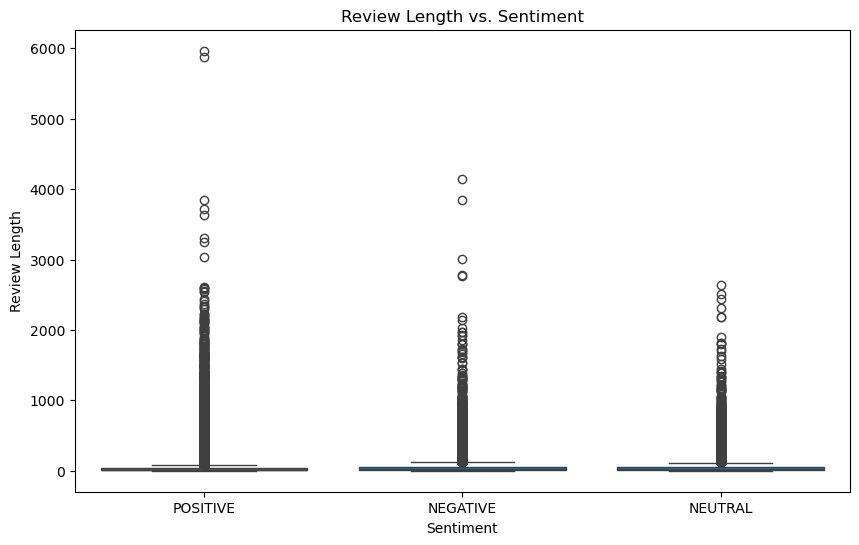

In [18]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='reviewText_length_words', data=data)
plt.title('Review Length vs. Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

In [19]:
Q1 = data['reviewText_length_words'].quantile(0.25)
Q3 = data['reviewText_length_words'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data['reviewText_length_words'][(data['reviewText_length_words'] < lower_bound) | (data['reviewText_length_words'] > upper_bound)]
print(f"Number of outliers in review length: {len(outliers)}")

Number of outliers in review length: 140335


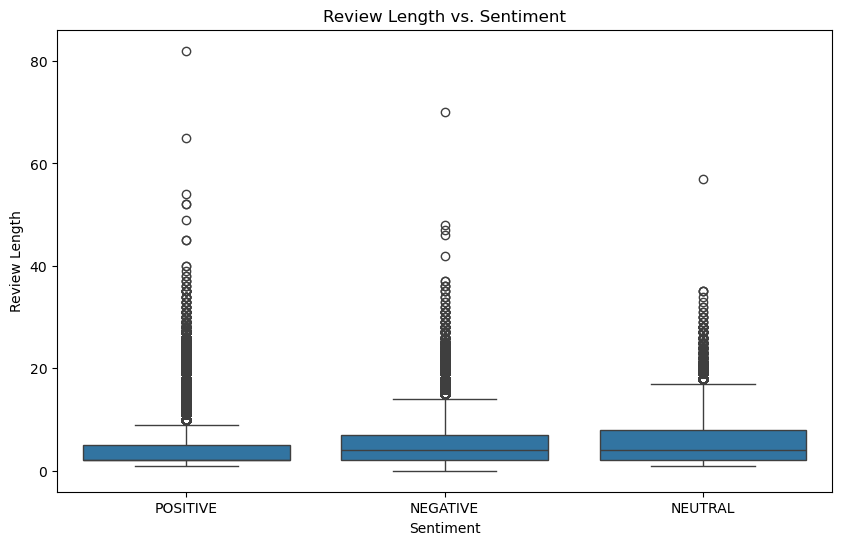

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='summary_length_words', data=data)
plt.title('Review Length vs. Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

In [21]:
Q1_s = data['summary_length_words'].quantile(0.25)
Q3_s = data['summary_length_words'].quantile(0.75)
IQR_s = Q3_s - Q1_s
lower_bound_s = Q1_s - 1.5 * IQR_s
upper_bound_s = Q3_s + 1.5 * IQR_s

outliers_s = data['summary_length_words'][(data['summary_length_words'] < lower_bound_s) | (data['summary_length_words'] > upper_bound_s)]
print(f"Number of outliers in review length: {len(outliers_s)}")

Number of outliers in review length: 191451


In [22]:
# Remove outliers
filtered_data = data[(data['reviewText_length_words'] >= lower_bound) & 
                     (data['reviewText_length_words'] <= upper_bound)]

print(f"Filtered data shape: {filtered_data.shape}")

Filtered data shape: (1494170, 15)


In [23]:
# Remove outliers
filtered_data = filtered_data[(filtered_data['summary_length_words'] >= lower_bound_s) & 
                     (filtered_data['summary_length_words'] <= upper_bound_s)]

print(f"Filtered data shape: {filtered_data.shape}")

Filtered data shape: (1333495, 15)


In [24]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1333495 entries, 0 to 1758332
Data columns (total 15 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   overall                  1333495 non-null  int64 
 1   verified                 1333495 non-null  bool  
 2   reviewTime               1333495 non-null  object
 3   reviewerID               1333495 non-null  object
 4   asin                     1333495 non-null  object
 5   reviewerName             1333421 non-null  object
 6   reviewText               1333495 non-null  object
 7   summary                  1333495 non-null  object
 8   unixReviewTime           1333495 non-null  int64 
 9   vote                     114321 non-null   object
 10  style                    537192 non-null   object
 11  image                    17150 non-null    object
 12  reviewText_length_words  1333495 non-null  int64 
 13  summary_length_words     1333495 non-null  int64 
 14  label  

In [25]:
from sklearn.model_selection import train_test_split

sampled_df, _ = train_test_split(filtered_data,
                                 train_size=2000,
                                 stratify=filtered_data['label'],
                                 random_state=42)

In [26]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 738371 to 9343
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   overall                  2000 non-null   int64 
 1   verified                 2000 non-null   bool  
 2   reviewTime               2000 non-null   object
 3   reviewerID               2000 non-null   object
 4   asin                     2000 non-null   object
 5   reviewerName             2000 non-null   object
 6   reviewText               2000 non-null   object
 7   summary                  2000 non-null   object
 8   unixReviewTime           2000 non-null   int64 
 9   vote                     178 non-null    object
 10  style                    794 non-null    object
 11  image                    23 non-null     object
 12  reviewText_length_words  2000 non-null   int64 
 13  summary_length_words     2000 non-null   int64 
 14  label                    2000 non-null  

In [27]:
sampled_df.head(5)

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,reviewText_length_words,summary_length_words,label
738371,5,True,"08 18, 2015",A15ZDMON8G1OI5,B00DCGWYKI,Art Rodriguez,Fast delivery and effective. Exactly what I wanted. Thank you!!,Five Stars,1439856000,NaN,NaN,NaN,10,2,POSITIVE
1179905,1,True,"08 19, 2016",A1RSNXJADULT5R,B01EJMLO8G,H C,"Operator manual confusing. Refers to wire feeding button and wire loading button, but no such buttons are shown on diagram. Pen heated up once and then quit working. Expensive b'day present that left angry child and frustrated parents. All the seller wanted was for me to write product review.",Poor product. Won't buy this again.,1471564800,15,NaN,NaN,49,6,NEGATIVE
1306888,1,True,"05 7, 2014",A1O8JACMOU1ZO1,B002PJEXEI,Matthew Hitzges,This stethoscope does not work properly. I recommend that you don't buy it. You will just be wasting your money.,Do Not Buy!,1399420800,NaN,NaN,NaN,20,3,NEGATIVE
1350654,5,True,"01 10, 2014",A1A1L113H9YOFS,B0058QKFBU,George H.,"I believe this is more than enough gaffer tape I will probably ever use.\n\nI just love the bright colors, just wish they had thrown in a roll of black also.",perfect rolls for travel!,1389312000,NaN,NaN,NaN,31,4,POSITIVE
461728,5,True,"09 16, 2013",A3UKWDXIOOEZH7,B0050CFIQY,Samantha,"if you ever seen a 3 oz. bath and body works lotion, then you know that this product is smaller then 1 oz. its 0.18 oz. but it came right on time and i like it.",There not as big as the picture,1379289600,NaN,{'Size:': ' Single Pack'},NaN,36,7,POSITIVE


In [28]:
sampled_df.to_csv("sampled_reviews.csv", index=False)